In [13]:
# imports
import pandas as pd 
import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
results = pd.read_csv('data/test_predictions.csv')

print(results.shape)
print(results['condition'].value_counts())
# as per 07_refit this should return
# gates: n=497 min 0.0238max 0.8364 mean 0.3563
print(results[results['condition'] == 'learned']['gate_value'].agg(['count', 'min', 'max', 'mean']))

(2982, 6)
condition
text            497
image           497
early           497
intermediate    497
late            497
learned         497
Name: count, dtype: int64
count    497.000000
min        0.023758
max        0.836425
mean       0.356278
Name: gate_value, dtype: float64


In [8]:
# balanced accuracy for each class
conditions = ['text', 'image', 'early', 'intermediate', 'late', 'learned']

score_rows = []

for condition in conditions:
    condition_rows = results[results['condition'] == condition]

    # separate between two groups
    # without buffer areas and with
    populations = [
        ('full', condition_rows),
        ('non_buffer', condition_rows[~condition_rows['in_buffer']])
    ]

    for population, population_rows in populations:
        true_labels = population_rows['true_label']
        predicted_labels = population_rows['predicted_label']

        score_rows.append({
            'condition': condition,
            'population': population,
            'n': len(population_rows),
            'balanced_accuracy': balanced_accuracy_score(true_labels, predicted_labels),
            'macro_f1': f1_score(true_labels, predicted_labels, average='macro')
        })

score_table = pd.DataFrame(score_rows)
print(score_table.round(4).to_string(index=False))

   condition population   n  balanced_accuracy  macro_f1
        text       full 497             0.4225    0.3854
        text non_buffer 360             0.4322    0.4243
       image       full 497             0.4076    0.3714
       image non_buffer 360             0.4210    0.4166
       early       full 497             0.4711    0.4123
       early non_buffer 360             0.4814    0.4664
intermediate       full 497             0.4295    0.3948
intermediate non_buffer 360             0.4345    0.4270
        late       full 497             0.4238    0.4036
        late non_buffer 360             0.4347    0.4348
     learned       full 497             0.4482    0.4025
     learned non_buffer 360             0.4526    0.4416


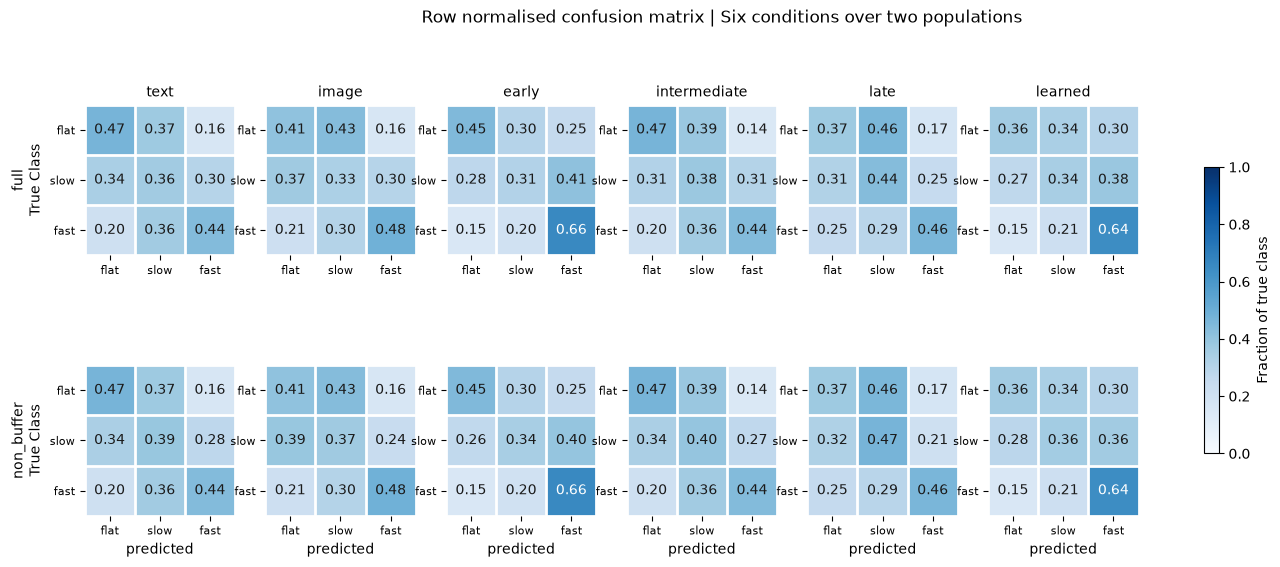

In [15]:
# confusion matrixes

class_order = [0, 1, 2]
class_names = ['flat', 'slow', 'fast']
populations = ['full', 'non_buffer']

figure, axes = plt.subplots(2, 6, figsize=(17, 6.2))

for row_index, population in enumerate(populations):
    for column_index, condition in enumerate(conditions):

        condition_rows = results[results['condition'] == condition]

        if population == 'non_buffer':
            condition_rows = condition_rows[~condition_rows['in_buffer']]

        # divide each row by its total
        # diagonal is per class recall
        matrix = confusion_matrix(
            condition_rows['true_label'],
            condition_rows['predicted_label'],
            labels=class_order,
            normalize='true'
        )

        axis = axes[row_index, column_index]

        # colour should mean the same thing in the 12 subplots
        heatmap = axis.imshow(matrix, cmap='Blues', vmin=0, vmax=1)

        for true_index in range(3):
            for predicted_index in range(3):
                cell_value = matrix[true_index, predicted_index]
                axis.text(
                    predicted_index, true_index, f'{cell_value:.2f}',
                    ha='center', va='center', fontsize=10, color='white' if cell_value > 0.5 else '#1a1a1a'
                )

        axis.set_xticks(range(3), class_names, fontsize=8)
        axis.set_yticks(range(3), class_names, fontsize=8)

        axis.set_xticks(np.arange(-0.5, 3, 1), minor=True)
        axis.set_yticks(np.arange(-0.5, 3, 1), minor=True)
        axis.grid(which='minor', color='white', linewidth=2)
        axis.tick_params(which='minor', length=0)

        for spine in axis.spines.values():
            spine.set_visible(False)

        if row_index == 0:
            axis.set_title(condition, fontsize=10)
        if column_index == 0:
            axis.set_ylabel(f'{population}\nTrue Class', fontsize=10)
        if row_index == 1:
            axis.set_xlabel('predicted', fontsize=10)

figure.suptitle('Row normalised confusion matrix | Six conditions over two populations')
figure.colorbar(heatmap, ax=axes, shrink=0.6, label='Fraction of true class')

plt.show()